## 1. Setup

In [ ]:
import os
import zipfile
import urllib.request

import numpy as np
import librosa
from tqdm.autonotebook import tqdm
from huggingface_hub import hf_hub_download

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import joblib
import matplotlib.pyplot as plt

N_FFT = 1 << 15
TARGET_SR = 44100
TRACKS_COUNT = 750
TRACK_DURATION = 180  # seconds
TEST_SIZE = 0.2
RANDOM_STATE = 67

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

## 2. Download real songs

In [42]:
import os
import pandas as pd
from tqdm import tqdm
from yt_dlp import YoutubeDL

# Configuration
CSV_PATH = "real_songs.csv"
OUTPUT_DIR = "real_songs"


def get_current_mp3_count(directory):
    """Accurately counts completed .mp3 files in the folder."""
    if not os.path.exists(directory):
        return 0
    return len([f for f in os.listdir(directory) if f.endswith(".mp3")])


def download_until_target(csv_path, output_dir, target):
    os.makedirs(output_dir, exist_ok=True)

    # 1. Check existing downloaded tracks
    initial_count = get_current_mp3_count(output_dir)
    if initial_count >= target:
        print("Done")
        return

    df = pd.read_csv(csv_path)
    valid_ids = df[df["youtube_id"].notna()]["youtube_id"].tolist()

    print(f"Current collection status: {initial_count} MP3s.")
    print(f"Need to download {target - initial_count} more files to reach target.")

    ydl_opts = {
        "format": "bestaudio/best",
        "outtmpl": os.path.join(output_dir, "%(id)s.%(ext)s"),
        "cookiesfrombrowser": ("firefox",),
        "postprocessors": [
            {
                "key": "FFmpegExtractAudio",
                "preferredcodec": "mp3",
                "preferredquality": "192",
            }
        ],
        "quiet": True,
        "no_warnings": True,
        "ignoreerrors": True,
    }

    current_count = initial_count

    pbar = tqdm(total=target, initial=current_count, desc="Progress")

    with YoutubeDL(ydl_opts) as ydl:
        for yt_id in valid_ids:
            # Hard stop condition evaluated before hitting network requests
            if current_count >= target:
                break

            expected_file = os.path.join(output_dir, f"{yt_id}.mp3")

            if os.path.exists(expected_file):
                continue

            video_url = f"https://www.youtube.com/watch?v={yt_id}"
            try:
                ydl.download([video_url])
                current_count += 1
                pbar.update(1)
            except Exception:
                pass  # Handled safely via yt-dlp ignoreerrors config

    pbar.close()
    final_count = get_current_mp3_count(output_dir)
    print(f"Done. {final_count} files dowloaded.")


download_until_target(CSV_PATH, OUTPUT_DIR, target=TRACKS_COUNT)


Done


## 3. Select mp3 files

In [48]:
import glob
import random


fake_songs = glob.glob(os.path.join("fake_songs", "**", "*.mp3"), recursive=True)
real_songs = glob.glob(os.path.join("real_songs", "**", "*.mp3"), recursive=True)

fake_songs = random.sample(fake_songs, min(TRACKS_COUNT, len(fake_songs)))
real_songs = random.sample(real_songs, min(TRACKS_COUNT, len(real_songs)))

print(f"Fake songs found: {len(fake_songs)}")
print(f"Real songs found: {len(real_songs)}")

Fake songs found: 750
Real songs found: 750


## 4. Process audio

In [49]:
CACHE_REAL = "data/real.npy"
CACHE_FAKE = "data/fake.npy"


def process_audio(file_list, output=None):
    result = []

    for f in tqdm(file_list, desc="Processing audio"):
        try:
            # Load track, resample and convert to mono
            y, sr = librosa.load(f, sr=TARGET_SR, duration=TRACK_DURATION, mono=True)
        except Exception:
            continue

        # Short time Fourier tranform
        stft = np.abs(librosa.stft(y, n_fft=N_FFT)) ** 2

        # Convert to log scale (dB)
        stft_db = 10 * np.log10(np.clip(stft, 1e-10, 1e9))

        # Calculate mean value for the bins
        mean = stft_db.mean(axis=1)

        # Calculate discrete difference between neighbouring bins
        diff = np.diff(mean)

        result.append(diff)

    result = np.array(result)

    if output is not None:
        np.save(output, result)
        print(f"Cached to {output}")

    return result


if os.path.exists(CACHE_REAL):
    print("Loading cached real features ...")
    x_real = np.load(CACHE_REAL)
else:
    x_real = process_audio(fake_songs, CACHE_REAL)

if os.path.exists(CACHE_FAKE):
    print("Loading cached AI features ...")
    x_fake = np.load(CACHE_FAKE)
else:
    x_fake = process_audio(real_songs, CACHE_FAKE)

print(f"Real features: {x_real.shape}, AI features: {x_fake.shape}")

Processing audio: 100%|██████████| 750/750 [01:08<00:00, 10.96it/s]


Cached to data/real.npy


Processing audio: 100%|██████████| 750/750 [01:52<00:00,  6.66it/s]


Cached to data/fake.npy
Real features: (750, 16384), AI features: (750, 16384)


## 5. Split datasets to test / train sets

In [52]:
x = np.concatenate([x_real, x_fake], axis=0)
y = np.concatenate([np.zeros(len(x_real)), np.ones(len(x_fake))], axis=0)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(y_train)} ({sum(y_train == 0)} real, {sum(y_train == 1)} AI)")
print(f"Test:  {len(y_test)} ({sum(y_test == 0)} real, {sum(y_test == 1)} AI)")

Train: 1200 (600 real, 600 AI)
Test:  300 (150 real, 150 AI)


## 6. Train PCA + XGBoost

In [54]:
pca = PCA(n_components=128)
xgb = XGBClassifier(
    learning_rate=0.05,
    n_estimators=600,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
)

if os.path.exists("models/xgb.json") and os.path.exists("models/pca.joblib"):
    print("Loading saved models ...")
    xgb.load_model("models/xgb.json")
    pca = joblib.load("models/pca.joblib")
else:
    print("Fitting PCA ...")
    x_tr = pca.fit_transform(x_train)
    print("Training XGBoost ...")
    xgb.fit(x_tr, y_train)
    joblib.dump(pca, "models/pca.joblib")
    xgb.save_model("models/xgb.json")

Fitting PCA ...
Training XGBoost ...


## 7. Evaluation

              precision    recall  f1-score   support

      Not AI       0.99      1.00      0.99       150
          AI       1.00      0.99      0.99       150

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



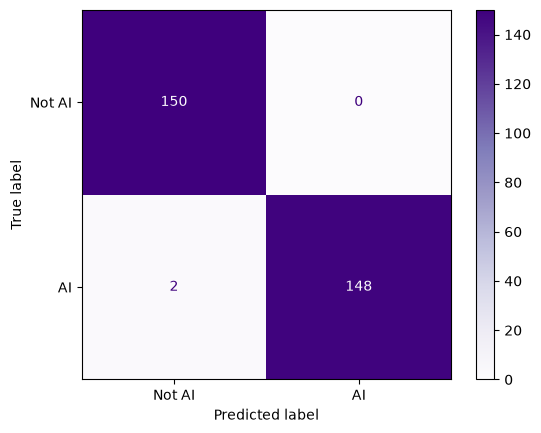

In [55]:
x_te = pca.transform(x_test)
y_pred = xgb.predict(x_te)

real_acc = np.mean(y_pred[y_test == 0] == 0)
synth_acc = np.mean(y_pred[y_test == 1] == 1)

print(classification_report(y_test, y_pred, target_names=["Not AI", "AI"]))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Not AI", "AI"], cmap="Purples"
)
plt.show()